In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
#Install pyxdf - https://github.com/xdf-modules/pyxdf
#pip install git+https://github.com/xdf-modules/pyxdf.git
import pyxdf

{'info': defaultdict(<class 'list'>, {'version': ['1.0'], 'datetime': ['2025-04-15T16:36:16+0200']})}
Keys in the stream: dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
Stream name: ['OpenSignals']
Stream type: ['00:07:80:8C:07:08']
Stream channel count: ['2']
Stream channel labels: []
Stream sampling rate: 1000


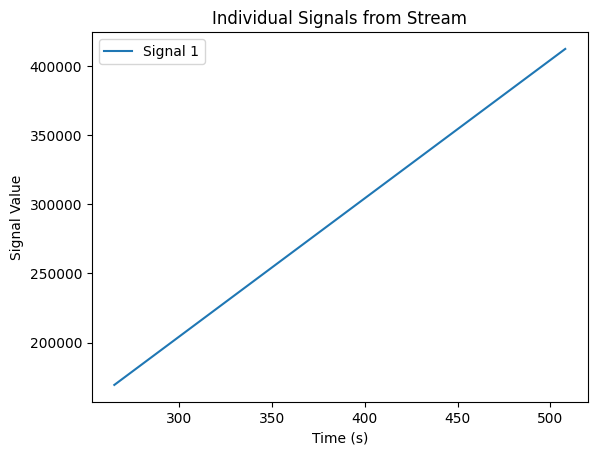

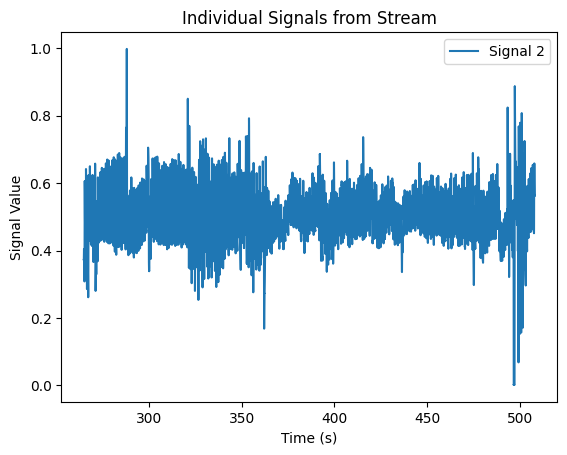

        Channel 1  Channel 2    Time (s)
0        169350.0   0.371975  264.905209
1        169351.0   0.372012  264.906209
2        169352.0   0.372090  264.907209
3        169353.0   0.371989  264.908209
4        169354.0   0.371693  264.909208
...           ...        ...         ...
243131   412481.0   0.563132  507.989676
243132   412482.0   0.562874  507.990676
243133   412483.0   0.562719  507.991676
243134   412484.0   0.562504  507.992675
243135   412485.0   0.562348  507.993675

[243136 rows x 3 columns]


In [35]:
#to look at the xdf file i would recommend using https://github.com/cbrnr/sigviewer?tab=readme-ov-file to get an overivew of streams and evenets
data, header = pyxdf.load_xdf("Test_Data\\test_task.xdf")
print(header)
# Initialize an empty list to store DataFrames for each stream
stream_dataframes = []
sampling_frequency = 1
for stream in data:
    y = stream["time_series"]
    time_stamps = stream["time_stamps"]
    keys = stream.keys()
    print("Keys in the stream:", keys)
    print("Stream name:", stream["info"]["name"])
    print("Stream type:", stream["info"]["type"])
    print("Stream channel count:", stream["info"]["channel_count"])
    print("Stream channel labels:", stream["info"]["channel_labels"])
    sampling_frequency = int(float(stream["info"]["nominal_srate"][0]))
    print("Stream sampling rate:", sampling_frequency)
    
    # Create a DataFrame for the current stream
    if isinstance(y, np.ndarray):
        # Numeric data
        df = pd.DataFrame(y, columns=[f"Channel {i+1}" for i in range(y.shape[1])])
        df["Time (s)"] = time_stamps
        stream_dataframes.append(df)

        # Plot each column of the time_series individually
        for i in range(y.shape[1]):
            plt.plot(time_stamps, y[:, i], label=f"Signal {i+1}")
            plt.xlabel("Time (s)")
            plt.ylabel("Signal Value")
            plt.title("Individual Signals from Stream")
            plt.legend()
            plt.show()

    elif isinstance(y, list):
        # List of strings (e.g., markers)
        df = pd.DataFrame({"Time": time_stamps, "Marker": y})
        stream_dataframes.append(df)

        # Plot markers as vertical lines
        for timestamp, marker in zip(time_stamps, y):
            plt.axvline(x=timestamp, color='r', linestyle='--')
            print(f'Marker "{marker[0]}" @ {timestamp:.2f}s')
        plt.title("Markers in Stream")
        plt.xlabel("Time (s)")
        plt.show()

    else:
        raise RuntimeError("Unknown stream format")

# Combine all stream DataFrames into a single DataFrame
combined_df = pd.concat(stream_dataframes, ignore_index=True)

# Print the combined DataFrame
print(combined_df)



{'info': defaultdict(<class 'list'>, {'version': ['1.0'], 'datetime': ['2025-04-28T18:34:03+0200']})}
Keys in the stream: dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
Stream name: ['DummyStream']
Stream type: ['Misc']
Stream channel count: ['3']
Stream channel labels: []
Stream sampling rate: 0


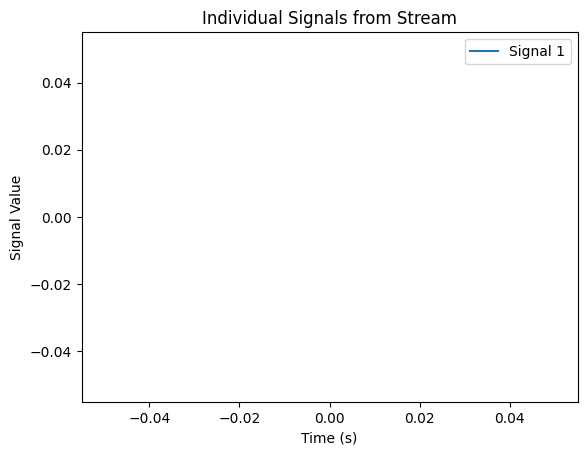

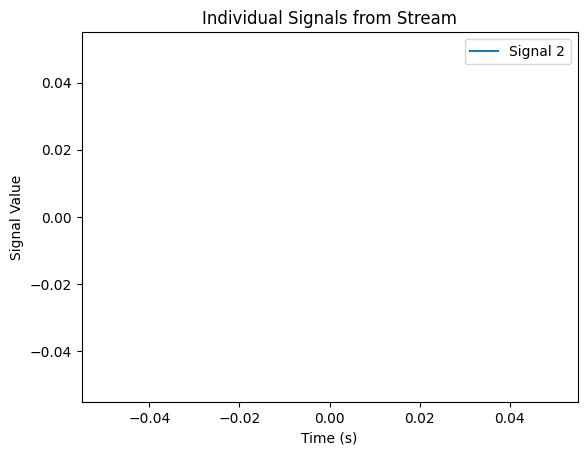

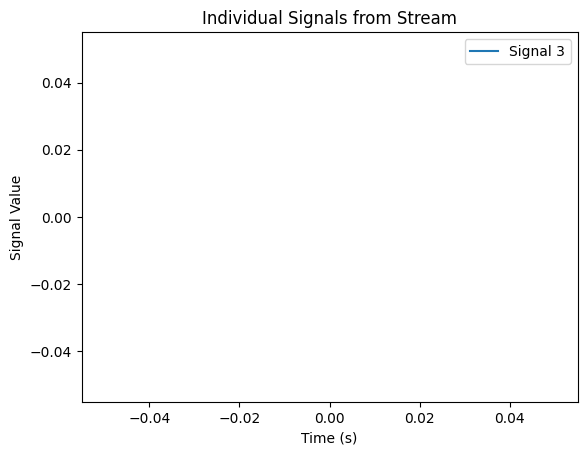

Keys in the stream: dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
Stream name: ['GazePointStream']
Stream type: ['Gaze']
Stream channel count: ['1']
Stream channel labels: []
Stream sampling rate: 0


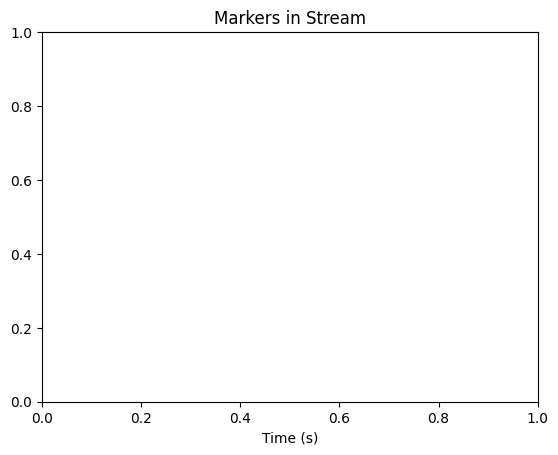

Keys in the stream: dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
Stream name: ['UnityMarkers']
Stream type: ['Markers']
Stream channel count: ['1']
Stream channel labels: []
Stream sampling rate: 0


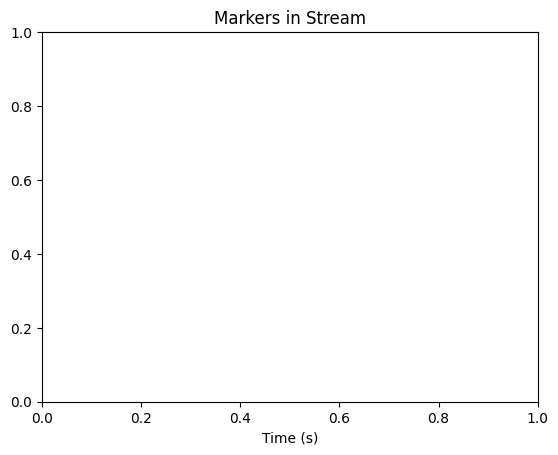

Keys in the stream: dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
Stream name: ['UnityMarkers']
Stream type: ['Markers']
Stream channel count: ['1']
Stream channel labels: []
Stream sampling rate: 0


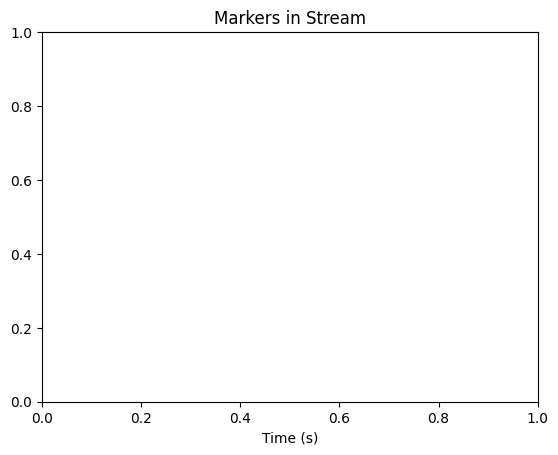

Keys in the stream: dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
Stream name: ['DummyStream']
Stream type: ['Misc']
Stream channel count: ['3']
Stream channel labels: []
Stream sampling rate: 0


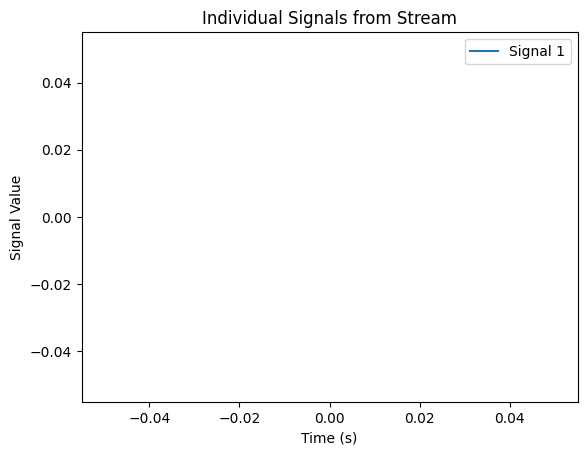

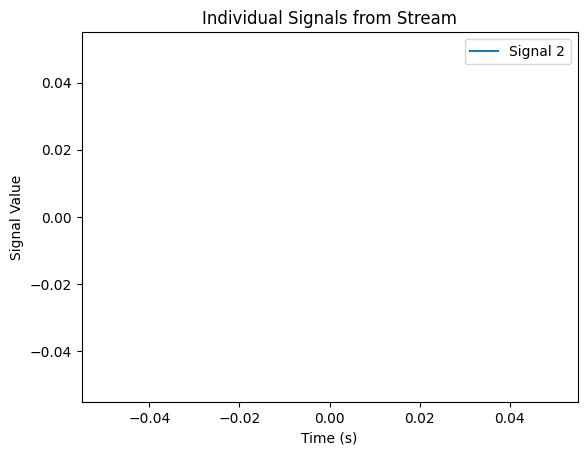

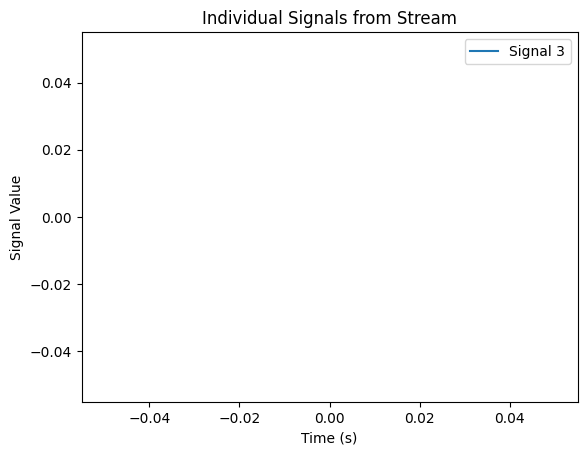

Empty DataFrame
Columns: [Channel 1, Channel 2, Channel 3, Time (s), Time, Marker]
Index: []


In [ ]:
#to look at the xdf file i would recommend using https://github.com/cbrnr/sigviewer?tab=readme-ov-file to get an overivew of streams and evenets
data, header = pyxdf.load_xdf("Test_Data\\dummydata.xdf")
print(header)
# Initialize an empty list to store DataFrames for each stream
stream_dataframes = []
sampling_frequency = 1
for stream in data:
    y = stream["time_series"]
    time_stamps = stream["time_stamps"]
    keys = stream.keys()
    print("Keys in the stream:", keys)
    print("Stream name:", stream["info"]["name"])
    print("Stream type:", stream["info"]["type"])
    print("Stream channel count:", stream["info"]["channel_count"])
    print("Stream channel labels:", stream["info"]["channel_labels"])
    sampling_frequency = int(float(stream["info"]["nominal_srate"][0]))
    print("Stream sampling rate:", sampling_frequency)
    print("First line of data:", y[0])
    
    # Create a DataFrame for the current stream
    if isinstance(y, np.ndarray):
        # Numeric data
        df = pd.DataFrame(y, columns=[f"Channel {i+1}" for i in range(y.shape[1])])
        df["Time (s)"] = time_stamps
        stream_dataframes.append(df)

        # Plot each column of the time_series individually
        for i in range(y.shape[1]):
            plt.plot(time_stamps, y[:, i], label=f"Signal {i+1}")
            plt.xlabel("Time (s)")
            plt.ylabel("Signal Value")
            plt.title("Individual Signals from Stream")
            plt.legend()
            plt.show()

    elif isinstance(y, list):
        # List of strings (e.g., markers)
        df = pd.DataFrame({"Time": time_stamps, "Marker": y})
        stream_dataframes.append(df)

        # Plot markers as vertical lines
        for timestamp, marker in zip(time_stamps, y):
            plt.axvline(x=timestamp, color='r', linestyle='--')
            print(f'Marker "{marker[0]}" @ {timestamp:.2f}s')
        plt.title("Markers in Stream")
        plt.xlabel("Time (s)")
        plt.show()

    else:
        raise RuntimeError("Unknown stream format")

# Combine all stream DataFrames into a single DataFrame
combined_df = pd.concat(stream_dataframes, ignore_index=True)

# Print the combined DataFrame
print(combined_df)



In [39]:
from scipy.signal import find_peaks

# Extract BVP signal and timestamps
bvp_signal = combined_df["Channel 2"].values  # Assuming BVP data is in "Channel 2"
timestamps = combined_df["Time (s)"].values

# Detect peaks in the BVP signal
peaks, _ = find_peaks(bvp_signal, distance=50)  # Adjust 'distance' based on sampling rate
# Calculate inter-beat intervals (IBIs) in seconds

print(sampling_frequency)

ibi = np.diff(timestamps[peaks]) / sampling_frequency

# Calculate heart rate (HR) in beats per minute (BPM)
heart_rate = 60 / ibi

# Create a new DataFrame with heart rate data
heart_rate_df = pd.DataFrame({
    "Time (s)": timestamps[peaks][1:],  # Exclude the first peak due to diff
    "Heart Rate (BPM)": heart_rate
})

# Display the heart rate DataFrame
print(heart_rate_df)


1000
        Time (s)  Heart Rate (BPM)
0     265.004190      6.186751e+05
1     265.248144      2.459487e+05
2     265.398115      4.000766e+05
3     265.629071      2.597900e+05
4     265.687059      1.034681e+06
...          ...               ...
1887  507.414786      2.166480e+05
1888  507.490771      7.896248e+05
1889  507.572756      7.318474e+05
1890  507.780716      2.885168e+05
1891  507.950683      3.530087e+05

[1892 rows x 2 columns]
